# BoTorch Hyperparameter Optimization (CPU-Only)

This notebook performs **multi-objective hyperparameter optimization** using **BoTorch qNEHVI** on your existing training pipeline.
Objectives:
- Maximize accuracy
- Minimize inference latency (CPU)
- Minimize model size (trainable parameters)

Designed specifically for **no-GPU / personal PC** execution.

In [ ]:
import os
import time
import random
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import torch

from botorch.acquisition.multi_objective.logei import qLogNoisyExpectedHypervolumeImprovement
from botorch.models import SingleTaskGP
from botorch.models.transforms.outcome import Standardize
from botorch.fit import fit_gpytorch_mll
from botorch.optim import optimize_acqf
from botorch.sampling.normal import SobolQMCNormalSampler
from botorch.utils.multi_objective.box_decompositions.non_dominated import NondominatedPartitioning

from gpytorch.mlls.exact_marginal_log_likelihood import ExactMarginalLogLikelihood

from data_loader import get_dataloaders, get_dataset_info, DEVICE, DEFAULT_TRAIN_SUBSET
from train_eval import train_and_evaluate

# Temporary upstream warning from torchvision + NumPy 2.4+ when reading CIFAR pickle metadata.
if hasattr(np, "VisibleDeprecationWarning"):
    warnings.filterwarnings(
        "ignore",
        message=r"dtype\(\): align should be passed as Python or NumPy boolean",
        category=np.VisibleDeprecationWarning,
    )

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Using device: {DEVICE}")
print(f"Default train subset from data_loader: {DEFAULT_TRAIN_SUBSET:,}")

PyTorch: 2.11.0+cpu
CUDA available: False
Using device: cpu
Default train subset from data_loader: 10,000


## CPU-Oriented Optimization Settings

These defaults intentionally trade search breadth for faster iteration on CPU:
- Smaller `train_subset_size`
- Lower epoch range
- Moderate trial budget (`N_INIT + N_BO_ITERS`)

You can increase them later once you confirm everything runs end-to-end.

In [5]:
@dataclass
class SearchChoices:
    arch_type: list
    num_conv_layers: list
    num_channels: list
    num_fc_units: list
    learning_rate: list
    batch_size: list
    num_epochs: list
    dropout_rate: list
    optimizer_type: list
    input_resolution: list


SEARCH = SearchChoices(
    arch_type=["plain", "residual", "depthwise_separable"],
    num_conv_layers=[1, 2, 3, 4],
    num_channels=[8, 16, 32, 64],
    num_fc_units=[32, 64, 128, 256],
    learning_rate=[1e-4, 3e-4, 1e-3, 3e-3],
    batch_size=[16, 32, 64],
    num_epochs=[3, 5, 8],
    dropout_rate=[0.0, 0.1, 0.2, 0.3, 0.4],
    optimizer_type=["Adam", "SGD"],
    input_resolution=[16, 32],
)

DATASET_NAME = "cifar10"
TRAIN_SUBSET_SIZE = "auto"  # same behavior as baseline_demo: 10K on CPU, 20K on GPU

N_INIT = 8
N_BO_ITERS = 12
Q = 1

CPU_REF_POINT = torch.tensor([0.0, -100.0, -20.0], dtype=torch.double)

# 10-d decision vector in [0, 1]^10
D = 10
BOUNDS = torch.stack([torch.zeros(D, dtype=torch.double), torch.ones(D, dtype=torch.double)])

print(f"Dataset: {DATASET_NAME}")
print(f"Train subset size setting: {TRAIN_SUBSET_SIZE}")
print(f"Total trials: {N_INIT + N_BO_ITERS}")

Dataset: cifar10
Train subset size setting: auto
Total trials: 20


In [6]:
# Baseline-style dataset loading sanity check (uses data_loader.py directly)
ds_info = get_dataset_info(DATASET_NAME)
train_loader, test_loader = get_dataloaders(
    dataset_name=DATASET_NAME,
    batch_size=64,
    train_subset_size=TRAIN_SUBSET_SIZE,
    test_subset_size=500,
    input_resolution=32,
    seed=SEED,
    num_workers=0,
 )
images, labels = next(iter(train_loader))

print(f"\n--- {DATASET_NAME} ---")
print(f"Classes      : {ds_info['num_classes']}  {ds_info['class_names']}")
print(f"Channels     : {ds_info['input_channels']}")
print(f"Resolution   : {ds_info['default_resolution']}x{ds_info['default_resolution']}")
print(f"Train samples: {len(train_loader.dataset):,}")
print(f"Test samples : {len(test_loader.dataset):,}")
print(f"Batch shape  : {images.shape}")
print(f"Pixel range  : [{images.min():.3f}, {images.max():.3f}]")

c:\CHAITYA\Web Dev Projects\MOML_Project\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")



--- cifar10 ---
Classes      : 10  ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Channels     : 3
Resolution   : 32x32
Train samples: 10,000
Test samples : 500
Batch shape  : torch.Size([64, 3, 32, 32])
Pixel range  : [-1.989, 2.126]


c:\CHAITYA\Web Dev Projects\MOML_Project\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [7]:
def pick_from_unit(u: float, choices: list):
    idx = int(np.clip(np.floor(u * len(choices)), 0, len(choices) - 1))
    return choices[idx]


def decode_x(x_unit: np.ndarray) -> dict:
    x = np.asarray(x_unit, dtype=float).reshape(-1)
    return {
        "arch_type": pick_from_unit(x[0], SEARCH.arch_type),
        "num_conv_layers": pick_from_unit(x[1], SEARCH.num_conv_layers),
        "num_channels": pick_from_unit(x[2], SEARCH.num_channels),
        "num_fc_units": pick_from_unit(x[3], SEARCH.num_fc_units),
        "learning_rate": pick_from_unit(x[4], SEARCH.learning_rate),
        "batch_size": pick_from_unit(x[5], SEARCH.batch_size),
        "num_epochs": pick_from_unit(x[6], SEARCH.num_epochs),
        "dropout_rate": pick_from_unit(x[7], SEARCH.dropout_rate),
        "optimizer_type": pick_from_unit(x[8], SEARCH.optimizer_type),
        "input_resolution": pick_from_unit(x[9], SEARCH.input_resolution),
    }


def objective_transform(raw: dict) -> torch.Tensor:
    # BoTorch assumes maximization; convert minimization objectives via negative sign.
    return torch.tensor([
        raw["accuracy"],
        -raw["inference_ms"],
        -(raw["param_count"] / 1_000_000.0),
    ], dtype=torch.double)


def evaluate_config_from_x(x: torch.Tensor, trial_id: int) -> tuple[dict, torch.Tensor]:
    cfg = decode_x(x.detach().cpu().numpy())
    try:
        # train_and_evaluate uses data_loader.get_dataloaders internally.
        # We pass num_workers=0 to match baseline notebook safety on Windows.
        raw = train_and_evaluate(
            config=cfg,
            dataset_name=DATASET_NAME,
            seed=SEED + trial_id,
            train_subset_size=TRAIN_SUBSET_SIZE,
            num_workers=0,
        )
    except Exception as exc:
        # Keep BO loop alive on occasional failed trials.
        print(f"Trial {trial_id} failed: {exc}")
        raw = {"accuracy": 0.0, "inference_ms": 1e3, "param_count": int(2e7)}

    y = objective_transform(raw)
    out = {**cfg, **raw}
    return out, y

## Run BoTorch qNEHVI Loop

Workflow:
1. Generate Sobol initial points
2. Evaluate each candidate using your training pipeline
3. Fit GP model on observed objective values
4. Use qNEHVI to propose the next candidate
5. Repeat

In [ ]:
from gpytorch.mlls.exact_marginal_log_likelihood import ExactMarginalLogLikelihood

results_rows = []

sobol = torch.quasirandom.SobolEngine(dimension=D, scramble=True, seed=SEED)
X = sobol.draw(N_INIT).to(dtype=torch.double)
Y_list = []

print(f"Running {N_INIT} Sobol init trials...")
for i in range(N_INIT):
    t0 = time.time()
    row, y = evaluate_config_from_x(X[i], trial_id=i)
    row["phase"] = "init"
    row["trial"] = i
    row["wall_time_s"] = time.time() - t0
    results_rows.append(row)
    Y_list.append(y)
    print(f"init {i:02d} | acc={row['accuracy']:.2%} | inf={row['inference_ms']:.3f} ms | params={row['param_count']:,}")

Y = torch.stack(Y_list, dim=0)

for bo_iter in range(N_BO_ITERS):
    trial_id = N_INIT + bo_iter
    print(f"\nBO iter {bo_iter + 1}/{N_BO_ITERS}")

    model = SingleTaskGP(X, Y, outcome_transform=Standardize(m=Y.shape[-1]))
    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    fit_gpytorch_mll(mll)

    partitioning = NondominatedPartitioning(ref_point=CPU_REF_POINT, Y=Y)
    sampler = SobolQMCNormalSampler(sample_shape=torch.Size([128]))

    acq = qLogNoisyExpectedHypervolumeImprovement(
        model=model,
        ref_point=CPU_REF_POINT.tolist(),
        X_baseline=X,
        sampler=sampler,
        prune_baseline=True,
    )

    candidate, _ = optimize_acqf(
        acq_function=acq,
        bounds=BOUNDS,
        q=Q,
        num_restarts=8,
        raw_samples=256,
    )

    new_x = candidate.detach().view(1, -1)

    t0 = time.time()
    row, new_y = evaluate_config_from_x(new_x[0], trial_id=trial_id)
    row["phase"] = "bo"
    row["trial"] = trial_id
    row["wall_time_s"] = time.time() - t0
    results_rows.append(row)

    X = torch.cat([X, new_x], dim=0)
    Y = torch.cat([Y, new_y.view(1, -1)], dim=0)

    print(f"bo   {trial_id:02d} | acc={row['accuracy']:.2%} | inf={row['inference_ms']:.3f} ms | params={row['param_count']:,}")

results_df = pd.DataFrame(results_rows)
print("\nOptimization complete.")
display(results_df.head())

Running 8 Sobol init trials...


Epoch 01/05:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 02/05:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 03/05:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 04/05:   0%|          | 0/625 [00:00<?, ?it/s]

...

Epoch 07/08:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 08/08:   0%|          | 0/313 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/313 [00:00<?, ?it/s]

bo   19 | acc=59.30% | inf=3.218 ms | params=970,858

Optimization complete.


,arch_type,num_conv_layers,num_channels,num_fc_units,learning_rate,batch_size,num_epochs,dropout_rate,optimizer_type,input_resolution,accuracy,inference_ms,param_count,phase,trial,wall_time_s
0,depthwise_separable,1,64,64,0.0010,16,5,0.3,Adam,32,0.4719,1.249928,11786,init,0,89.379625
1,plain,3,16,256,0.0003,64,8,0.1,SGD,16,0.3547,0.611043,43018,init,1,44.736027
2,plain,2,32,32,0.0001,64,3,0.1,SGD,16,0.1811,0.475110,21994,init,2,20.741411
3,depthwise_separable,4,8,128,0.0030,32,5,0.4,Adam,32,0.4923,2.129254,8514,init,3,60.346650
4,residual,2,16,128,0.0030,16,3,0.0,SGD,16,0.4558,1.156159,25626,init,4,51.327127


In [9]:
def pareto_mask(values: np.ndarray, maximize: list[bool]) -> np.ndarray:
    n = values.shape[0]
    keep = np.ones(n, dtype=bool)
    signed = values.copy()
    for j, is_max in enumerate(maximize):
        if not is_max:
            signed[:, j] *= -1.0

    for i in range(n):
        if not keep[i]:
            continue
        dominates_i = np.all(signed >= signed[i], axis=1) & np.any(signed > signed[i], axis=1)
        if np.any(dominates_i):
            keep[i] = False
    return keep

vals = results_df[["accuracy", "inference_ms", "param_count"]].to_numpy(dtype=float)
mask = pareto_mask(vals, maximize=[True, False, False])
pareto_df = results_df.loc[mask].sort_values("accuracy", ascending=False).reset_index(drop=True)

print(f"Total trials: {len(results_df)}")
print(f"Pareto points: {len(pareto_df)}")
display(pareto_df[["trial", "phase", "arch_type", "accuracy", "inference_ms", "param_count"]])

Total trials: 20
Pareto points: 11


,trial,phase,arch_type,accuracy,inference_ms,param_count
0,13,bo,plain,0.6570,3.886753,970858
1,15,bo,plain,0.6286,3.625205,996490
2,9,bo,plain,0.6221,3.277073,970858
3,14,bo,plain,0.6081,2.414635,245994
4,3,init,depthwise_separable,0.4923,2.129254,8514
5,0,init,depthwise_separable,0.4719,1.249928,11786
6,8,bo,plain,0.4701,0.869108,80490
7,4,init,residual,0.4558,1.156159,25626
8,6,init,residual,0.3592,1.163585,6402
9,1,init,plain,0.3547,0.611043,43018


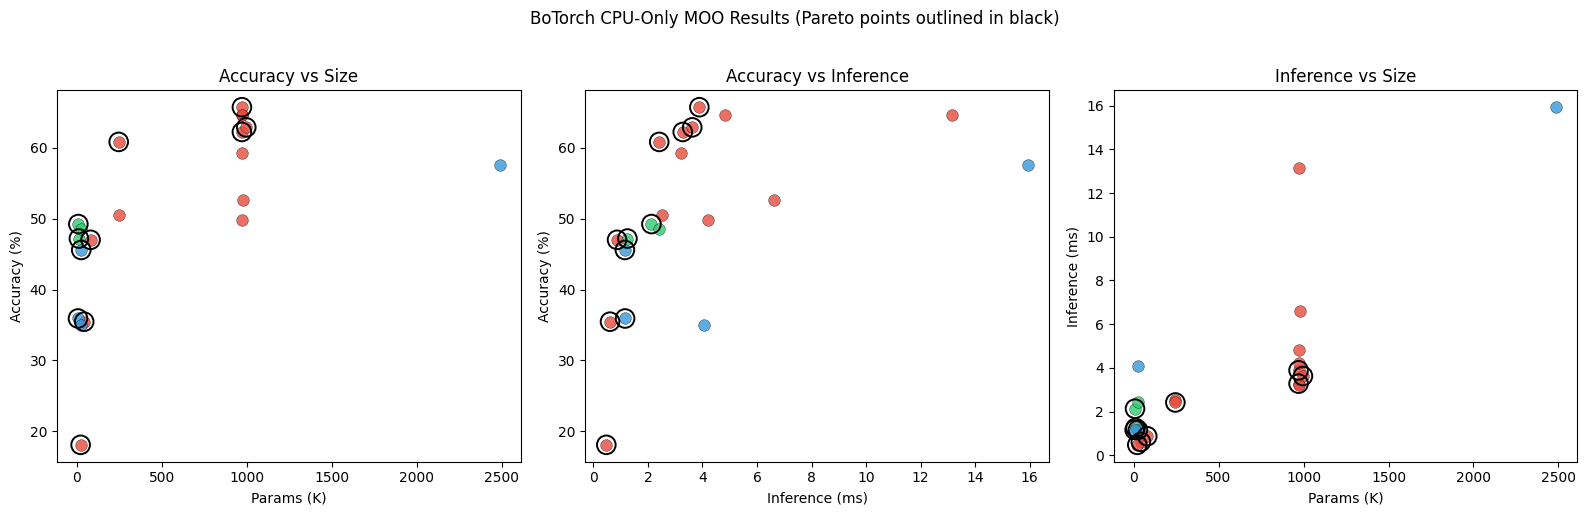

In [10]:
import matplotlib.pyplot as plt

colors = {"plain": "#e74c3c", "residual": "#3498db", "depthwise_separable": "#2ecc71"}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for _, r in results_df.iterrows():
    p = r["param_count"] / 1000.0
    a = r["accuracy"] * 100.0
    t = r["inference_ms"]
    c = colors.get(r["arch_type"], "gray")

    axes[0].scatter(p, a, c=c, s=70, alpha=0.8, edgecolors="k", linewidths=0.3)
    axes[1].scatter(t, a, c=c, s=70, alpha=0.8, edgecolors="k", linewidths=0.3)
    axes[2].scatter(p, t, c=c, s=70, alpha=0.8, edgecolors="k", linewidths=0.3)

for _, r in pareto_df.iterrows():
    p = r["param_count"] / 1000.0
    a = r["accuracy"] * 100.0
    t = r["inference_ms"]
    axes[0].scatter(p, a, facecolors="none", edgecolors="black", s=180, linewidths=1.4)
    axes[1].scatter(t, a, facecolors="none", edgecolors="black", s=180, linewidths=1.4)
    axes[2].scatter(p, t, facecolors="none", edgecolors="black", s=180, linewidths=1.4)

axes[0].set_title("Accuracy vs Size")
axes[0].set_xlabel("Params (K)")
axes[0].set_ylabel("Accuracy (%)")

axes[1].set_title("Accuracy vs Inference")
axes[1].set_xlabel("Inference (ms)")
axes[1].set_ylabel("Accuracy (%)")

axes[2].set_title("Inference vs Size")
axes[2].set_xlabel("Params (K)")
axes[2].set_ylabel("Inference (ms)")

fig.suptitle("BoTorch CPU-Only MOO Results (Pareto points outlined in black)", y=1.02)
plt.tight_layout()
plt.show()

In [11]:
os.makedirs("results", exist_ok=True)
all_path = os.path.join("results", "botorch_cpu_trials.csv")
pareto_path = os.path.join("results", "botorch_cpu_pareto.csv")

results_df.to_csv(all_path, index=False)
pareto_df.to_csv(pareto_path, index=False)

print(f"Saved all trials to: {all_path}")
print(f"Saved pareto trials to: {pareto_path}")

Saved all trials to: results\botorch_cpu_trials.csv
Saved pareto trials to: results\botorch_cpu_pareto.csv


## Notes

- Start with `cifar10`, then repeat with `fashion_mnist`.
- On CPU, avoid very large trial counts at first.
- If runtime is still high, reduce `N_BO_ITERS`, `TRAIN_SUBSET_SIZE`, or `num_epochs` choices.